In [8]:
import numpy as np
import matplotlib.pyplot as plt


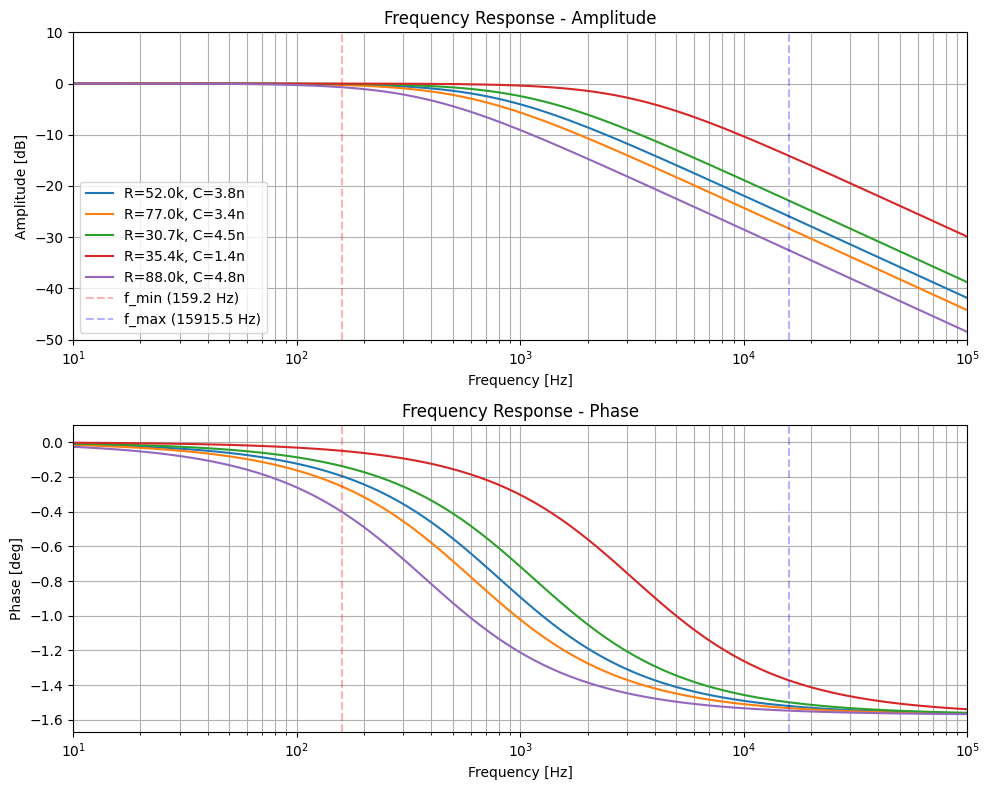

In [9]:
# Parameters for sampling
num_samples = 5
R_range = [10e3, 100e3]  # 10k to 100k
C_range = [1e-9, 10e-9] # 1n to 10n

# Uniform sampling
R_samples = np.random.uniform(R_range[0], R_range[1], num_samples)
C_samples = np.random.uniform(C_range[0], C_range[1], num_samples)

# Frequency range for analysis (1Hz to 1MHz)
f = np.logspace(1, 5, 100)
w = 2 * np.pi * f

# Calculate Transfer Function for all samples at once (Vectorized)
# Shape of R_samples[:, None]: (num_samples, 1)
# Shape of w: (len(f),)
# Resulting H shape: (num_samples, len(f))
H_all = 1 / (1 + 1j * w * R_samples[:, None] * C_samples[:, None])

# Calculate min and max cutoff frequencies (f = 1 / (2 * pi * R * C))
f_min = 1 / (2 * np.pi * R_range[1] * C_range[1])
f_max = 1 / (2 * np.pi * R_range[0] * C_range[0])

def plot_frequency_response(H_all, f, R_samples, C_samples):
  plt.figure(figsize=(10, 8))

  # Amplitude Plot
  plt.subplot(2, 1, 1)
  for i in range(num_samples):
      plt.semilogx(f, 20 * np.log10(np.abs(H_all[i])), label=f'R={R_samples[i]/1e3:.1f}k, C={C_samples[i]/1e-9:.1f}n')

  # Add boundary lines
  plt.axvline(f_min, color='red', linestyle='--', alpha=0.3, label=f'f_min ({f_min:.1f} Hz)')
  plt.axvline(f_max, color='blue', linestyle='--', alpha=0.3, label=f'f_max ({f_max:.1f} Hz)')

  plt.title('Frequency Response - Amplitude')
  plt.xlabel('Frequency [Hz]')
  plt.ylabel('Amplitude [dB]')
  plt.xlim(f.min(), f.max())
  plt.ylim(-50, 10)
  plt.grid(True, which="both", ls="-")
  plt.legend()

  # Phase Plot
  plt.subplot(2, 1, 2)
  for i in range(num_samples):
      plt.semilogx(f, np.angle(H_all[i]))

  plt.axvline(f_min, color='red', linestyle='--', alpha=0.3)
  plt.axvline(f_max, color='blue', linestyle='--', alpha=0.3)

  plt.title('Frequency Response - Phase')
  plt.xlabel('Frequency [Hz]')
  plt.ylabel('Phase [deg]')
  plt.xlim(f.min(), f.max())
  plt.ylim(-np.pi/2-0.1, 0.1)
  plt.grid(True, which="both", ls="-")

  plt.tight_layout()
  plt.show()

plot_frequency_response(H_all, f, R_samples, C_samples)


In [10]:
import torch
from torch.utils.data import Dataset
import numpy as np

class RCDataset(Dataset):
    def __init__(self, num_samples, R_range, C_range, fs):
        """
        Args:
            num_samples: Number of data points to generate
            R_range: [min_R, max_R]
            C_range: [min_C, max_C]
            fs: The frequency array (Hz) to evaluate H for
        """
        self.num_samples = num_samples
        self.f = torch.tensor(fs, dtype=torch.float32)
        self.w = 2 * torch.pi * self.f

        # Uniformly sample R and C
        self.R = torch.distributions.Uniform(R_range[0], R_range[1]).sample((num_samples, 1))
        self.C = torch.distributions.Uniform(C_range[0], C_range[1]).sample((num_samples, 1))

        # Calculate Complex Transfer Function: H(jw) = 1 / (1 + jwRC)
        # Shape: (num_samples, len(fs))
        jwRC = 1j * self.w * self.R * self.C
        self.H = 1 / (1 + jwRC)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # To match the expected format for plotting/analysis:
        # Returns (H, R, C)
        H = self.H[idx]   # Complex frequency response
        r = self.R[idx]   # Resistance value
        c = self.C[idx]   # Capacitance value

        return H, r, c

# Instantiate the dataset
fs = np.logspace(1, 5, 100)
dataset = RCDataset(num_samples=1000, R_range=[10e3, 100e3], C_range=[1e-9, 10e-9], fs=fs)


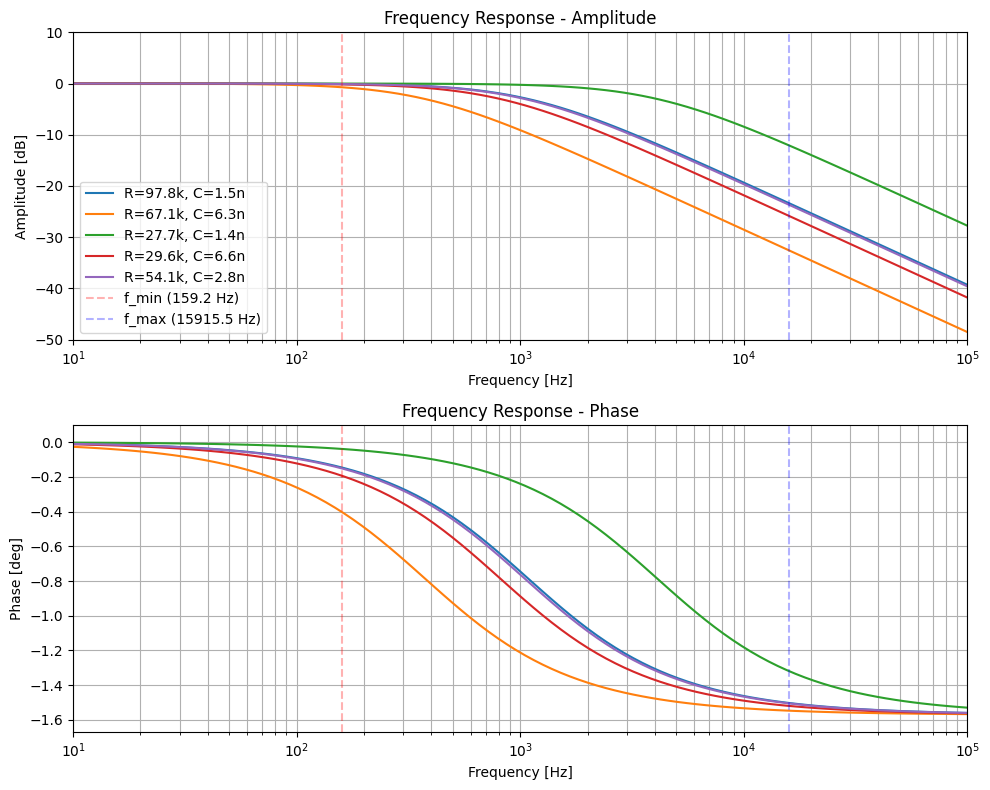

In [11]:
# Fetch a few samples from the dataset to plot
num_plot_samples = 5
H_list = []
R_list = []
C_list = []

for i in range(num_plot_samples):
    h, r, c = dataset[i]
    # Convert tensors back to numpy for the plotting function
    H_list.append(h.numpy())
    R_list.append(r.item())
    C_list.append(c.item())

# Convert to numpy arrays to match plot_frequency_response expectations
H_plot = np.array(H_list)
R_plot = np.array(R_list)
C_plot = np.array(C_list)

# Call the plotting function defined in cell 7cfd21e4
plot_frequency_response(H_plot, dataset.f.numpy(), R_plot, C_plot)


# 順問題
回路パラメータから周波数特性を求めるNN

(R, C) -> fs

In [12]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the Forward Model
class ForwardNN(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, output_size=200):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.net(x)

# 1. Extract raw data from dataset
H_all, R_all, C_all = dataset[:]

# Raw Inputs (Log scale as a base feature is still good practice for parameters spanning decades)
inputs_raw = torch.cat([torch.log10(R_all), torch.log10(C_all)], dim=1).numpy()

# Raw Targets: Magnitude (dB) and Phase (rad)
mag = 20 * torch.log10(torch.abs(H_all) + 1e-9)
phase = torch.angle(H_all)
targets_raw = torch.cat([mag, phase], dim=1).numpy()

# 2. Split into Train/Val first to compute stats only on training set
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    inputs_raw, targets_raw, test_size=0.2, random_state=42
)

# 3. Fit StandardScaler on Training data only
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train_raw)
X_val = scaler_x.transform(X_val_raw)

# Scale y_train and y_val
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train_raw)
y_val = scaler_y.transform(y_val_raw)

# Convert to Tensors
train_db = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_db = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))

train_loader = DataLoader(train_db, batch_size=32, shuffle=True)
val_loader = DataLoader(val_db, batch_size=32)

# Initialize model, loss, and optimizer
device = "cpu"
model = ForwardNN(output_size=targets_raw.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(f"Model initialized on {device}")
print(f"StandardScaler fit on {len(X_train)} samples.")


Model initialized on cpu
StandardScaler fit on 800 samples.


Epoch 0/101, Train Loss: 0.2178, Val Loss: 0.0356
Epoch 20/101, Train Loss: 0.0006, Val Loss: 0.0002
Epoch 40/101, Train Loss: 0.0016, Val Loss: 0.0006
Epoch 60/101, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 80/101, Train Loss: 0.0025, Val Loss: 0.0012
Epoch 100/101, Train Loss: 0.0000, Val Loss: 0.0000


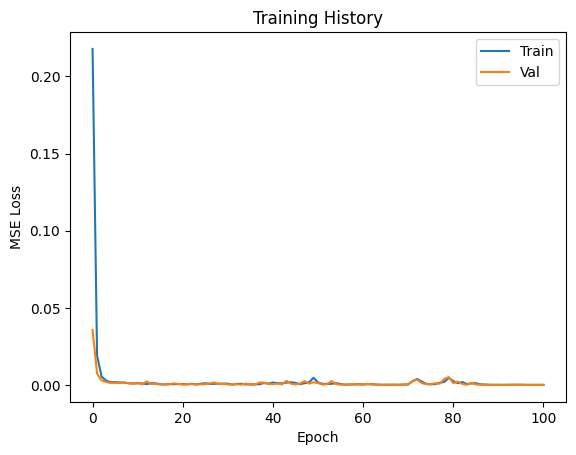

In [13]:
# Training Loop
epochs = 101
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_losses.append(np.mean(batch_losses))

    # Validation
    model.eval()
    with torch.no_grad():
        v_losses = [criterion(model(xb.to(device)), yb.to(device)).item() for xb, yb in val_loader]
        val_losses.append(np.mean(v_losses))

    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


### 予測結果と実測値の比較
検証データからランダムにサンプルを抽出し、学習済みモデルの予測精度を確認します。

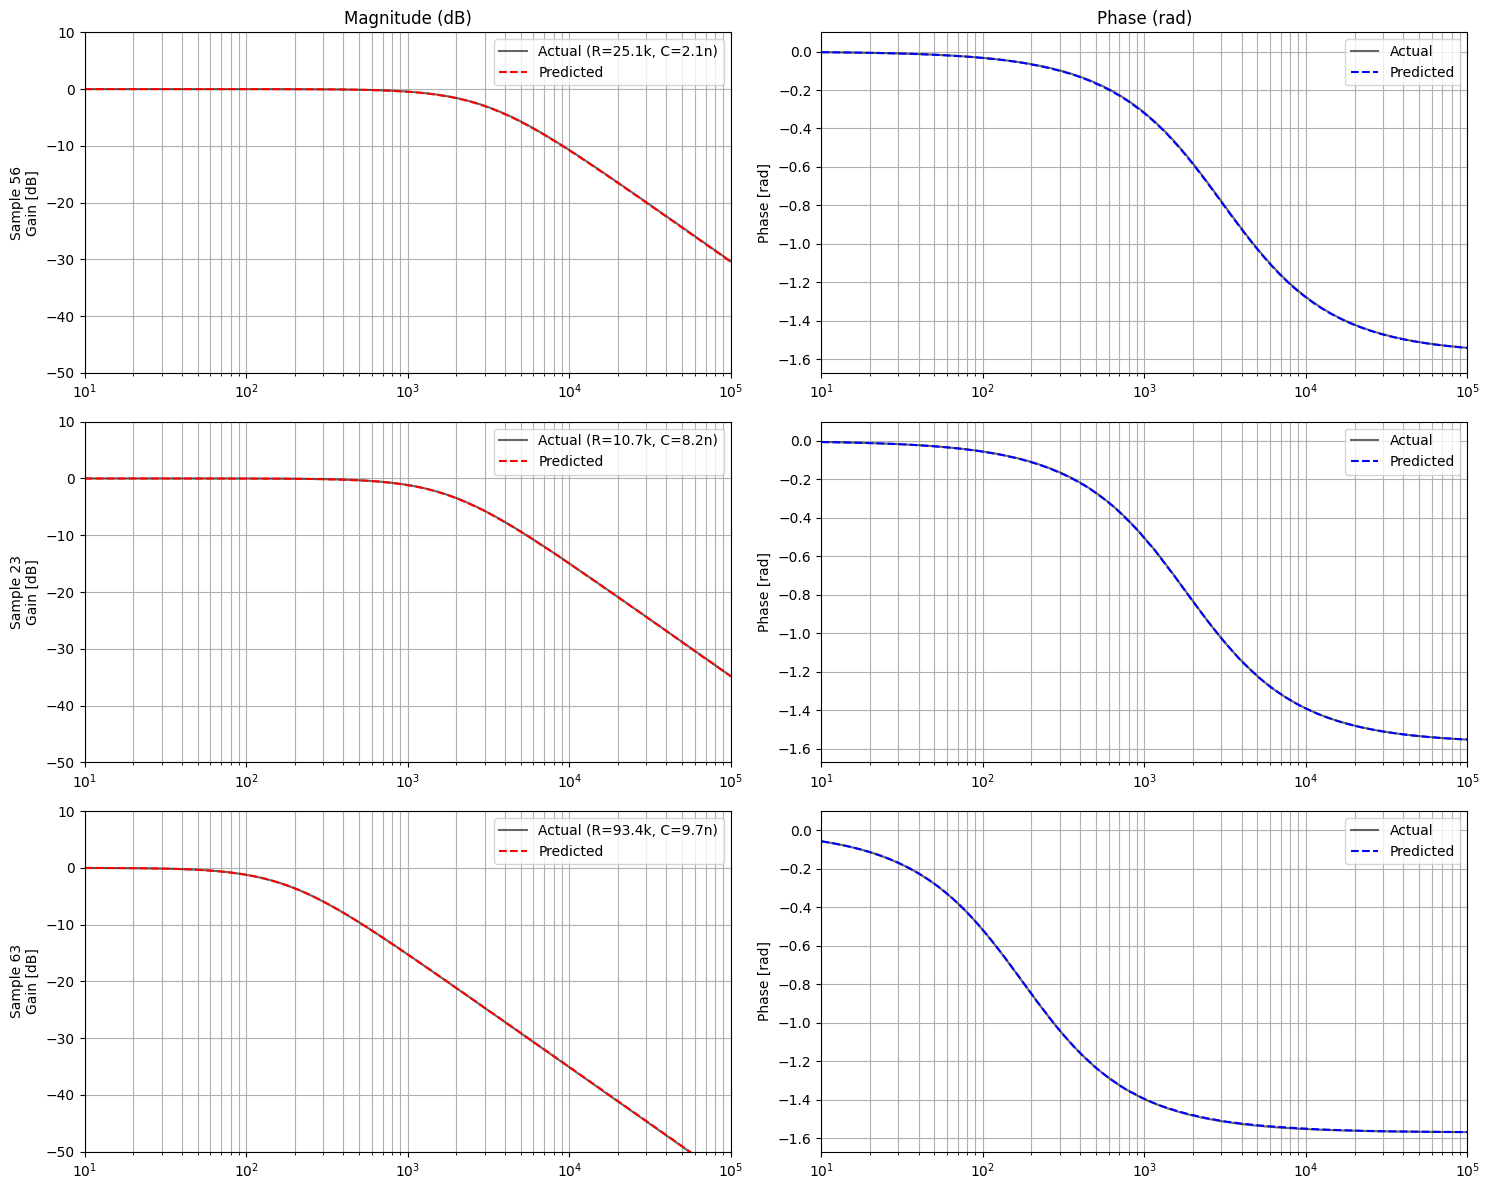

In [14]:
import random

def compare_predictions(model, X_val, y_val, scaler_x, scaler_y, freqs, num_samples=3):
    model.eval()
    indices = random.sample(range(len(X_val)), num_samples)

    plt.figure(figsize=(15, 4 * num_samples))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Prepare input
            x_input = torch.FloatTensor(X_val[idx]).unsqueeze(0).to(device)
            y_scaled_actual = y_val[idx]

            # Restore R, C values
            x_raw = scaler_x.inverse_transform(x_input.reshape(1, -1))[0]
            r_val = 10**x_raw[0]
            c_val = 10**x_raw[1]

            # Predict and inverse transform
            y_scaled_pred = model(x_input).cpu().numpy().flatten()
            y_raw_actual = scaler_y.inverse_transform(y_scaled_actual.reshape(1, -1))[0]
            y_raw_pred = scaler_y.inverse_transform(y_scaled_pred.reshape(1, -1))[0]

            # Split mag and phase
            mid = len(y_raw_actual) // 2
            mag_actual, phase_actual = y_raw_actual[:mid], y_raw_actual[mid:]
            mag_pred, phase_pred = y_raw_pred[:mid], y_raw_pred[mid:]

            # Magnitude plot
            plt.subplot(num_samples, 2, 2*i + 1)
            plt.semilogx(freqs, mag_actual, 'k-', label=f'Actual (R={r_val/1e3:.1f}k, C={c_val/1e-9:.1f}n)', alpha=0.6)
            plt.semilogx(freqs, mag_pred, 'r--', label='Predicted')
            if i == 0: plt.title('Magnitude (dB)')
            plt.ylabel(f'Sample {idx}\nGain [dB]')
            plt.xlim(f.min(), f.max())
            plt.ylim(-50, 10)
            plt.grid(True, which="both", ls="-")
            plt.legend()

            # Phase plot
            plt.subplot(num_samples, 2, 2*i + 2)
            plt.semilogx(freqs, phase_actual, 'k-', label='Actual', alpha=0.6)
            plt.semilogx(freqs, phase_pred, 'b--', label='Predicted')
            if i == 0: plt.title('Phase (rad)')
            plt.ylabel('Phase [rad]')
            plt.xlim(f.min(), f.max())
            plt.ylim(-np.pi/2 - 0.1, 0.1)
            plt.grid(True, which="both", ls="-")
            plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function to visualize results
compare_predictions(model, X_val, y_val, scaler_x, scaler_y, dataset.f.numpy(), num_samples=3)


# 逆問題
f -> (R, C)

In [15]:
# Define the inverse Model
class InvNN(nn.Module):
    def __init__(self, input_size=200, hidden_size=64, output_size=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.net(x)


inv_model = InvNN(output_size=inputs_raw.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(inv_model.parameters(), lr=0.01)

print(f"Model initialized on {device}")


Model initialized on cpu


Epoch 0/101, Train Loss: 0.6271, Val Loss: 0.4848
Epoch 20/101, Train Loss: 0.5189, Val Loss: 0.4712
Epoch 40/101, Train Loss: 0.5206, Val Loss: 0.4742
Epoch 60/101, Train Loss: 0.5241, Val Loss: 0.4732
Epoch 80/101, Train Loss: 0.5207, Val Loss: 0.4746
Epoch 100/101, Train Loss: 0.5192, Val Loss: 0.4684


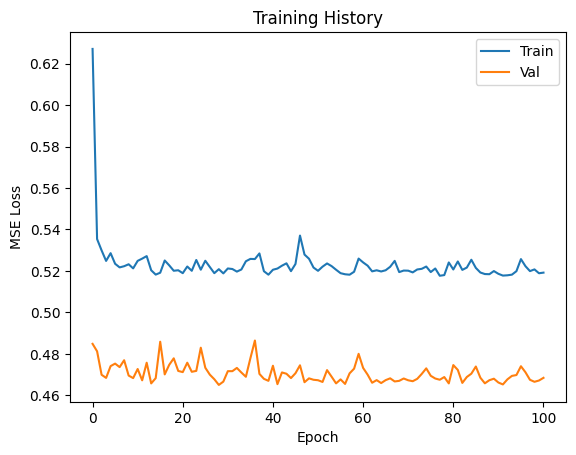

In [16]:
# Training Loop
epochs = 101
train_losses = []
val_losses = []

for epoch in range(epochs):
    inv_model.train()
    batch_losses = []
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = inv_model(y_batch) # inverse
        loss = criterion(outputs, x_batch) # inverse
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_losses.append(np.mean(batch_losses))

    # Validation
    inv_model.eval()
    with torch.no_grad():
        v_losses = [criterion(inv_model(yb.to(device)), xb.to(device)).item() for xb, yb in val_loader]
        val_losses.append(np.mean(v_losses))

    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


In [ ]:
import random

# モデルを評価モードに設定
inv_model.eval()

# 検証データからランダムに数サンプル抽出
num_samples_to_show = 3
indices = random.sample(range(len(X_val)), num_samples_to_show)

# プロットの作成
plt.figure(figsize=(15, 10))

with torch.no_grad():
    for i, idx in enumerate(indices):
        # データの準備
        x_input = torch.FloatTensor(X_val[idx]).unsqueeze(0).to(device)
        y_actual = torch.FloatTensor(y_val[idx]).unsqueeze(0).to(device)

        # R, C の値を復元 (scaler -> log10 -> raw)
        x_raw = scaler_x.inverse_transform(x_input.reshape(1, -1))[0]
        r_val = 10**x_raw[0]
        c_val = 10**x_raw[1]

        # 予測
        x_pred = inv_model(y_actual).cpu().numpy().flatten()

        # ターゲットは [mag (100), phase (100)] の構成
        y_actual = y_actual.squeeze(0)
        mid = len(y_actual) // 2
        mag_actual = y_actual[:mid]
        phase_actual = y_actual[mid:]
        mag_pred = y_pred[:mid]
        phase_pred = y_pred[mid:]

        # 周波数軸（データセット作成時のものを使用）
        freqs = dataset.f.numpy()

        # --- 振幅 (Magnitude) のプロット ---
        plt.subplot(num_samples_to_show, 2, 2*i + 1)
        plt.semilogx(freqs, mag_actual, 'k-', label=f'Actual (R={r_val/1e3:.1f}k, C={c_val/1e-9:.1f}n)', alpha=0.6)
        plt.semilogx(freqs, mag_pred, 'r--', label='Predicted')
        if i == 0: plt.title('Magnitude (dB)')
        plt.ylabel(f'Sample {idx}\nGain [dB]')
        plt.grid(True, which="both", ls="-")
        plt.legend()

        # --- 位相 (Phase) のプロット ---
        plt.subplot(num_samples_to_show, 2, 2*i + 2)
        plt.semilogx(freqs, phase_actual, 'k-', label='Actual', alpha=0.6)
        plt.semilogx(freqs, phase_pred, 'b--', label='Predicted')
        if i == 0: plt.title('Phase (rad)')
        plt.ylabel('Phase [rad]')
        plt.ylim(-np.pi/2 -0.1, 0.1)
        plt.grid(True, which="both", ls="-")
        plt.legend()

plt.tight_layout()
plt.show()


NameError: name 'scaler' is not defined

<Figure size 1500x1000 with 0 Axes>

## Rを固定することで逆問題の解を一意にする